In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, glob, math
import pandas as pd
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
import matplotlib.ticker as mticker


plt.rcParams.update({'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 9})

OUT_DIR        = '/oak/stanford/groups/ettore88/nberrios'
vp             = 3200.0
vs             = 1600.0
dz_m           = 1.0
which          = 'day'   # 'day' or 'night'
CHUNK_DAYS     = 7
xlim_show      = 1    # s

CHUNK_MODE = 'calendar_strict'   # 'calendar_strict' or 'available_files'

CATALOG        = 'NCEDC'
PARKFIELD_LAT  = 35.9747
PARKFIELD_LON  = -120.5522
RADIUS_KM      = 30.0
MIN_MAG        = 1.0

MAG_BINS       = [1.0, 2.0, 3.0, 4.0,10.0]
MAG_LABELS     = ['1-2', '2-3', '3-4', '4+']
MAG_COLORS     = ['#1B3A4B', '#4F6D7A', '#A7BBC7', '#EAF2F8']



## Build 7-day stacks

In [14]:
all_files = sorted(glob.glob(os.path.join(OUT_DIR, f'*_{which}.npz')))
print(f'Found {len(all_files)} {which} files')
print(f'  First: {os.path.basename(all_files[0])}')
print(f'  Last:  {os.path.basename(all_files[-1])}')

file_df = pd.DataFrame({
    'path': all_files,
    'date': [
        pd.Timestamp(os.path.basename(f).replace(f'_{which}.npz', ''), tz='UTC')
        for f in all_files
    ],
}).sort_values('date').reset_index(drop=True)

chunks = []
if CHUNK_MODE == 'calendar_strict':
    file_map = dict(zip(file_df['date'], file_df['path']))
    week_starts = pd.date_range(
        file_df['date'].min(),
        file_df['date'].max(),
        freq=f'{CHUNK_DAYS}D',
    )

    for week_start in week_starts:
        week_dates = pd.date_range(week_start, periods=CHUNK_DAYS, freq='1D', tz='UTC')
        week_files = [file_map.get(d) for d in week_dates]
        missing_dates = [d.strftime('%Y-%m-%d') for d, f in zip(week_dates, week_files) if f is None]

        if missing_dates:
            print(
                f"Skipping {week_start.strftime('%Y-%m-%d')} — "
                f"{week_dates[-1].strftime('%Y-%m-%d')} "
                f"(missing {len(missing_dates)} day(s): {', '.join(missing_dates)})"
            )
            continue

        chunks.append({
            'week_start': week_start,
            'week_end': week_dates[-1],
            'files': week_files,
            'expected_dates': week_dates,
            'missing_dates': missing_dates,
            'mode': CHUNK_MODE,
        })

    print(f'{len(chunks)} strict calendar {CHUNK_DAYS}-day chunk(s) kept')

elif CHUNK_MODE == 'available_files':
    file_chunks = [
        file_df.iloc[i:i+CHUNK_DAYS].copy()
        for i in range(0, len(file_df), CHUNK_DAYS)
    ]
    if len(file_chunks[-1]) < CHUNK_DAYS:
        print(f'Dropping incomplete last available-files chunk ({len(file_chunks[-1])} days)')
        file_chunks = file_chunks[:-1]

    for chunk_df in file_chunks:
        files = chunk_df['path'].tolist()
        dates = chunk_df['date'].tolist()
        expected_dates = pd.date_range(dates[0], periods=CHUNK_DAYS, freq='1D', tz='UTC')
        missing_dates = [
            d.strftime('%Y-%m-%d')
            for d in expected_dates
            if d not in set(dates)
        ]

        chunks.append({
            'week_start': dates[0],
            'week_end': dates[-1],
            'files': files,
            'expected_dates': expected_dates,
            'missing_dates': missing_dates,
            'mode': CHUNK_MODE,
        })

    print(f'{len(chunks)} available-files {CHUNK_DAYS}-file chunk(s) kept')

else:
    raise ValueError("CHUNK_MODE must be 'calendar_strict' or 'available_files'")

# find global min_nlag across files that are actually used
used_files = sorted({f for chunk in chunks for f in chunk['files']})
min_nlag = min(
    np.load(f, allow_pickle=True)['cc_combo'].shape[1]
    for f in used_files
)

# load metadata from first used file
meta     = np.load(used_files[0], allow_pickle=True)
dt       = float(meta['dt'])
max_lag  = float(meta['max_lag'])
ch_start = int(meta['ch_start'])
ch_end   = int(meta['ch_end'])
src      = int(meta['src'])
channels = np.arange(ch_start, ch_end)
lags     = np.linspace(-max_lag, max_lag, min_nlag)
dist     = np.abs(channels - src) * dz_m

# stack each chunk
stacks = []
for chunk in chunks:
    cc_sum = np.zeros((ch_end - ch_start, min_nlag))
    nstack = 0
    for f in chunk['files']:
        d = np.load(f, allow_pickle=True)
        nd = int(d['nstack_combo'])
        cc_sum += d['cc_combo'][:, :min_nlag] * nd
        nstack += nd

    cc_mean = cc_sum / nstack
    d0 = chunk['week_start'].strftime('%Y-%m-%d')
    d1 = chunk['week_end'].strftime('%Y-%m-%d')
    t0 = chunk['week_start']
    t1 = chunk['week_end'] + pd.Timedelta(days=1)

    stacks.append({
        'label': f'{d0}\n{d1}',
        'date_start': d0,
        'date_end': d1,
        'start_utc': t0,
        'end_utc': t1,
        'nstack': nstack,
        'nfiles_present': len(chunk['files']),
        'missing_dates': chunk['missing_dates'],
        'chunk_mode': chunk['mode'],
        'cc': cc_mean,
    })
    print(
        f"  {d0} — {d1}: nstack={nstack}, "
        f"nfiles={len(chunk['files'])}/{CHUNK_DAYS}, "
        f"missing={len(chunk['missing_dates'])}"
    )

query_start = min(s['start_utc'] for s in stacks)
query_end   = max(s['end_utc'] for s in stacks)
print(f'Event query window: {query_start} to {query_end}')

client = Client(CATALOG)
catalog = client.get_events(
    starttime=query_start.to_pydatetime(),
    endtime=query_end.to_pydatetime(),
    minmagnitude=MIN_MAG,
    latitude=PARKFIELD_LAT,
    longitude=PARKFIELD_LON,
    maxradius=RADIUS_KM / 111.32,
    includearrivals=False,
)

rows = []
for event in catalog:
    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]
    distance_m, _, _ = gps2dist_azimuth(
        PARKFIELD_LAT,
        PARKFIELD_LON,
        origin.latitude,
        origin.longitude,
    )
    rows.append({
        'time_utc': pd.Timestamp(origin.time.datetime, tz='UTC'),
        'latitude': origin.latitude,
        'longitude': origin.longitude,
        'depth_km': np.nan if origin.depth is None else origin.depth / 1000.0,
        'magnitude': magnitude.mag,
        'magnitude_type': magnitude.magnitude_type,
        'distance_km': distance_m / 1000.0,
    })

events_df = pd.DataFrame(rows)
if len(events_df) == 0:
    events_df = pd.DataFrame(columns=['time_utc', 'latitude', 'longitude', 'depth_km', 'magnitude', 'magnitude_type', 'distance_km'])
else:
    events_df = events_df.sort_values('time_utc').reset_index(drop=True)
    events_df = events_df[events_df['distance_km'] <= RADIUS_KM].reset_index(drop=True)

for s in stacks:
    mask = (events_df['time_utc'] >= s['start_utc']) & (events_df['time_utc'] < s['end_utc'])
    s['events'] = events_df.loc[mask].copy()
    s['nevents'] = len(s['events'])

print(f'Total events in catalog selection: {len(events_df)}')
print('Events per stack:')
for s in stacks:
    print(f"  {s['date_start']} — {s['date_end']}: nevents={s['nevents']}")



Found 116 day files
  First: 2024-05-07_day.npz
  Last:  2024-11-29_day.npz
Skipping 2024-05-14 — 2024-05-20 (missing 4 day(s): 2024-05-17, 2024-05-18, 2024-05-19, 2024-05-20)
Skipping 2024-05-21 — 2024-05-27 (missing 1 day(s): 2024-05-21)
Skipping 2024-07-09 — 2024-07-15 (missing 3 day(s): 2024-07-13, 2024-07-14, 2024-07-15)
Skipping 2024-07-16 — 2024-07-22 (missing 7 day(s): 2024-07-16, 2024-07-17, 2024-07-18, 2024-07-19, 2024-07-20, 2024-07-21, 2024-07-22)
Skipping 2024-07-23 — 2024-07-29 (missing 7 day(s): 2024-07-23, 2024-07-24, 2024-07-25, 2024-07-26, 2024-07-27, 2024-07-28, 2024-07-29)
Skipping 2024-07-30 — 2024-08-05 (missing 7 day(s): 2024-07-30, 2024-07-31, 2024-08-01, 2024-08-02, 2024-08-03, 2024-08-04, 2024-08-05)
Skipping 2024-08-06 — 2024-08-12 (missing 7 day(s): 2024-08-06, 2024-08-07, 2024-08-08, 2024-08-09, 2024-08-10, 2024-08-11, 2024-08-12)
Skipping 2024-08-13 — 2024-08-19 (missing 7 day(s): 2024-08-13, 2024-08-14, 2024-08-15, 2024-08-16, 2024-08-17, 2024-08-18, 2024

## Plot 7-day stacks with seismicity


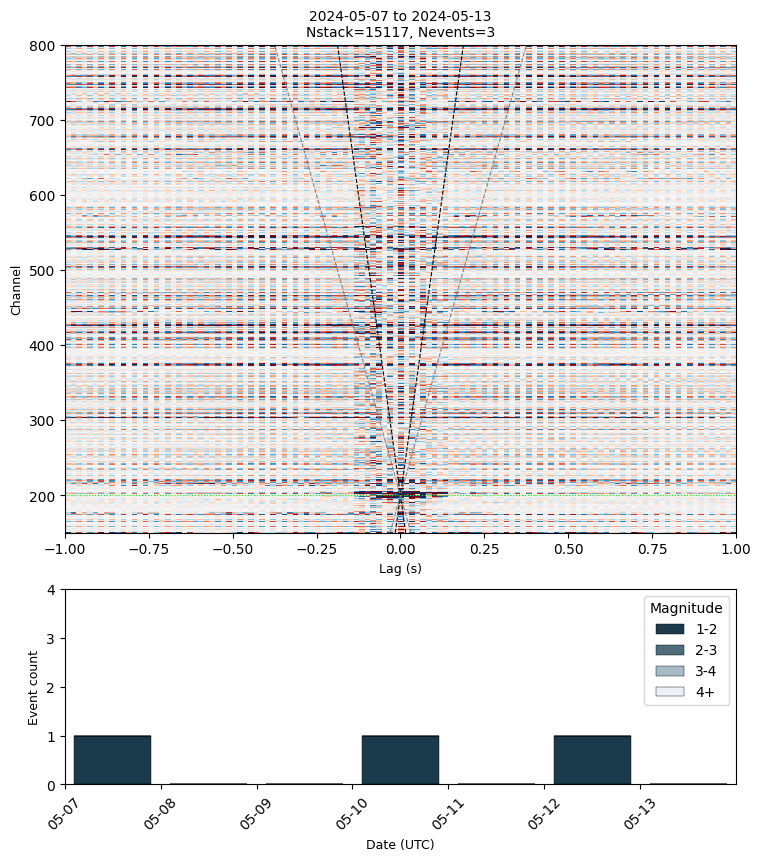

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-05-07_to_2024-05-13.png


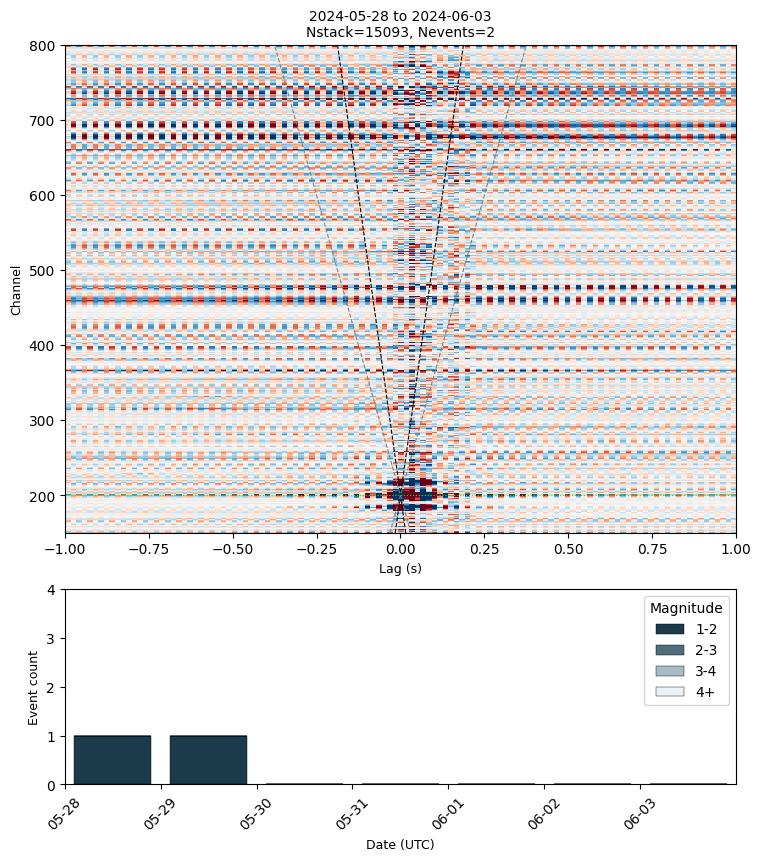

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-05-28_to_2024-06-03.png


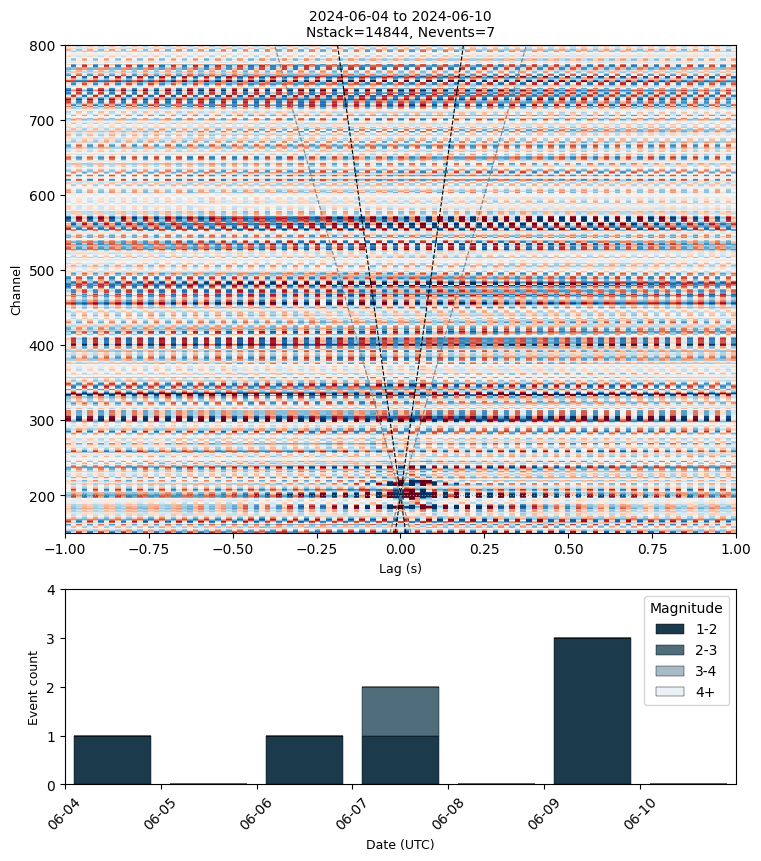

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-06-04_to_2024-06-10.png


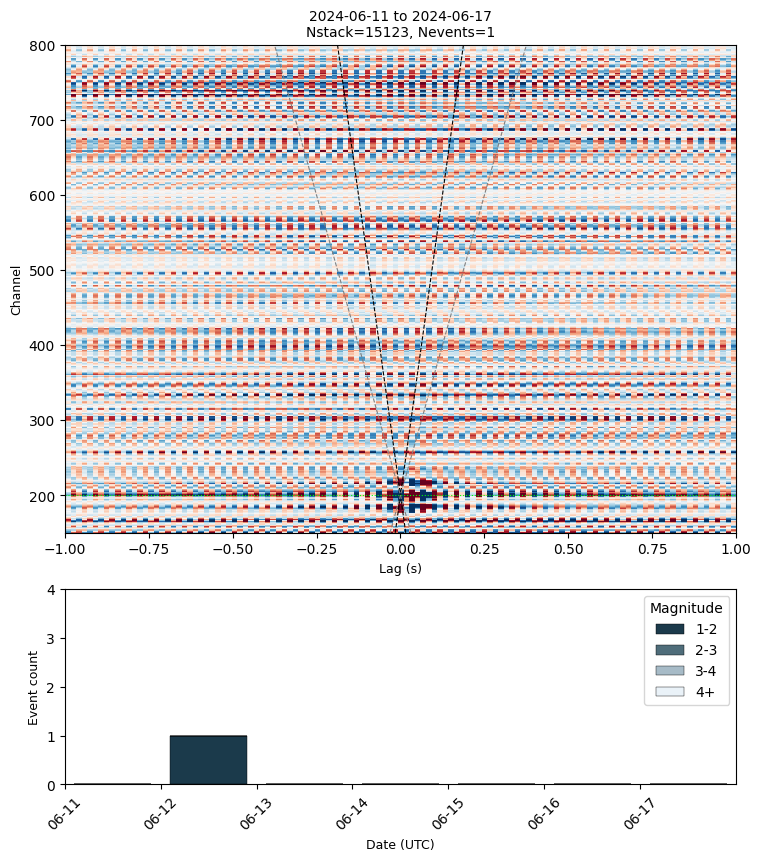

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-06-11_to_2024-06-17.png


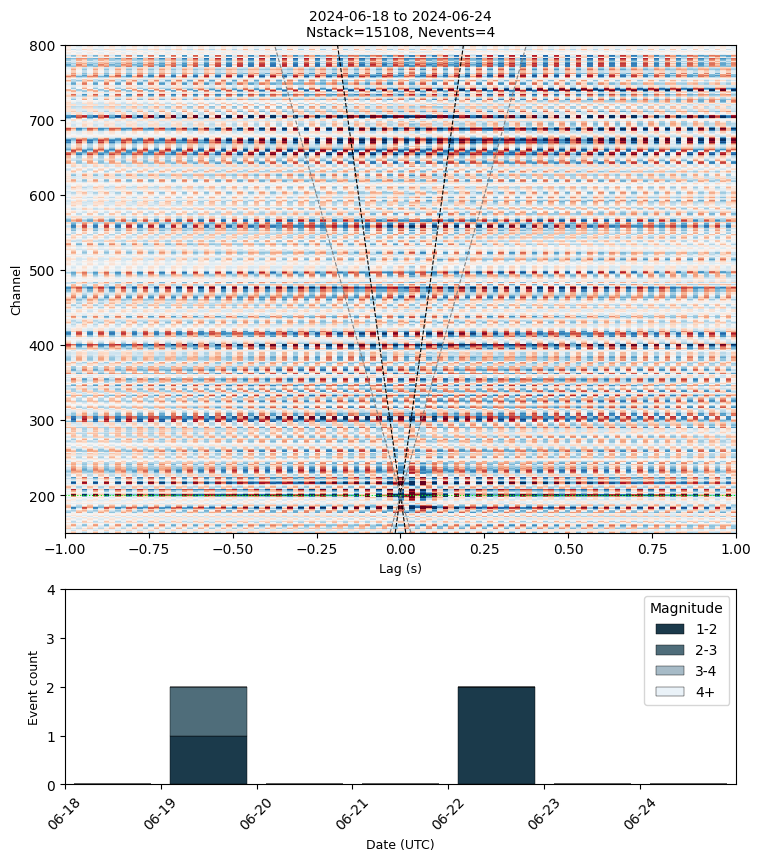

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-06-18_to_2024-06-24.png


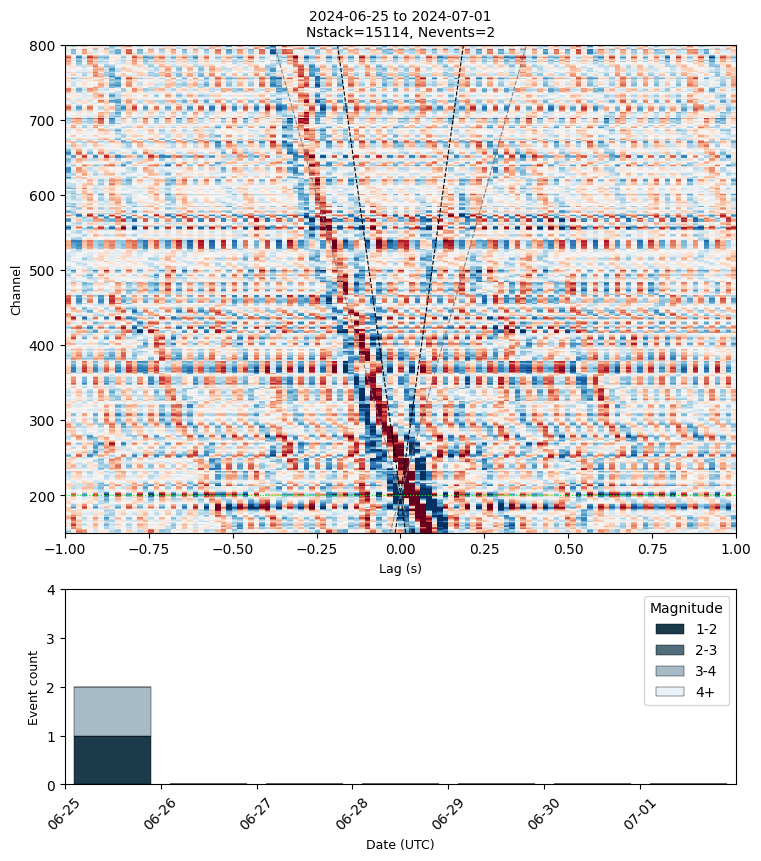

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-06-25_to_2024-07-01.png


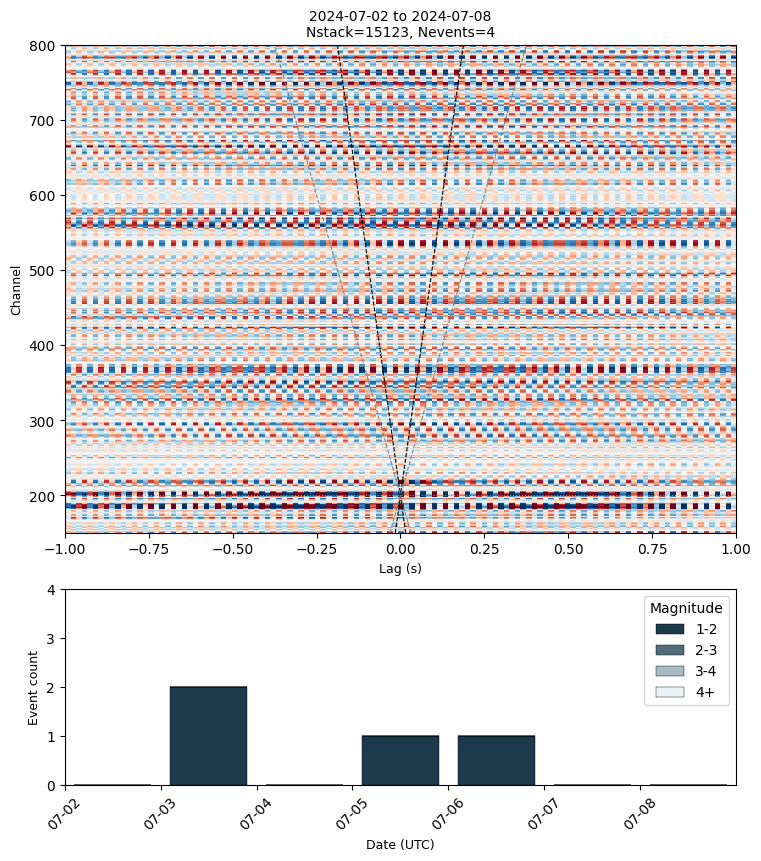

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-07-02_to_2024-07-08.png


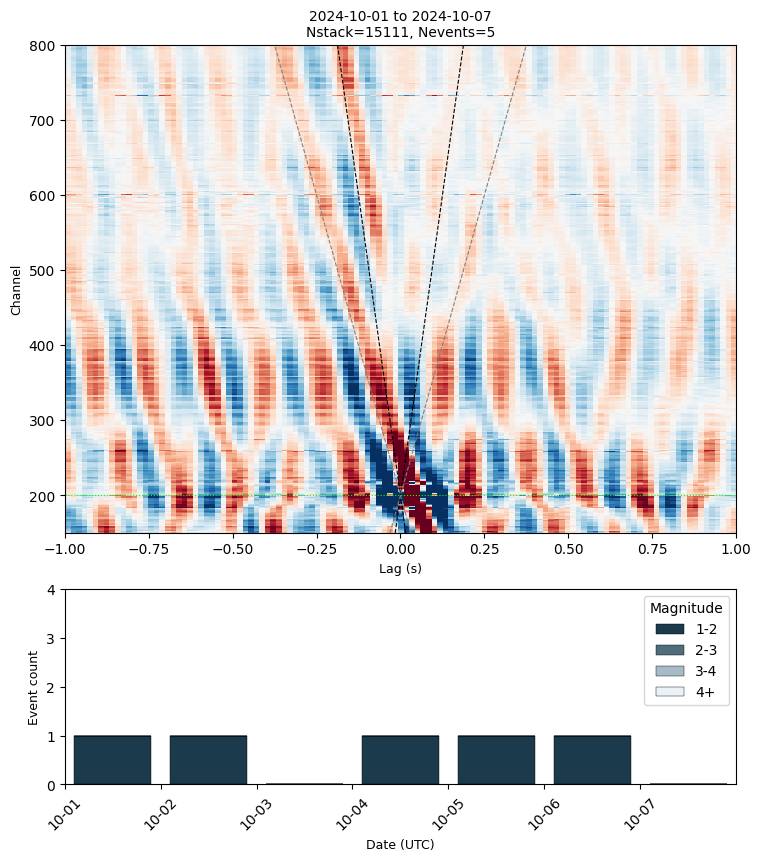

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-10-01_to_2024-10-07.png


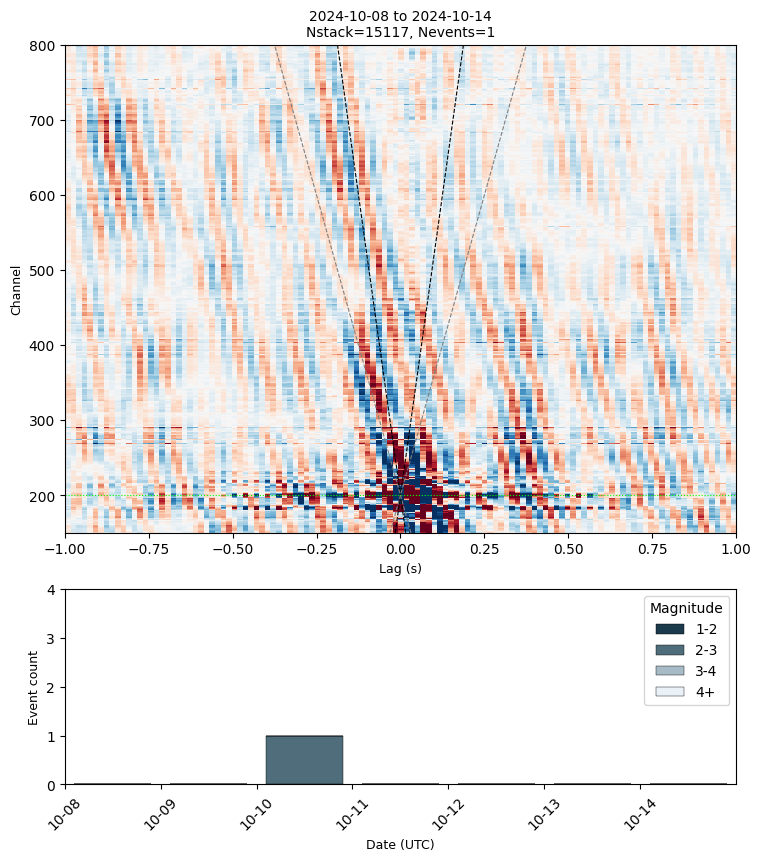

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-10-08_to_2024-10-14.png


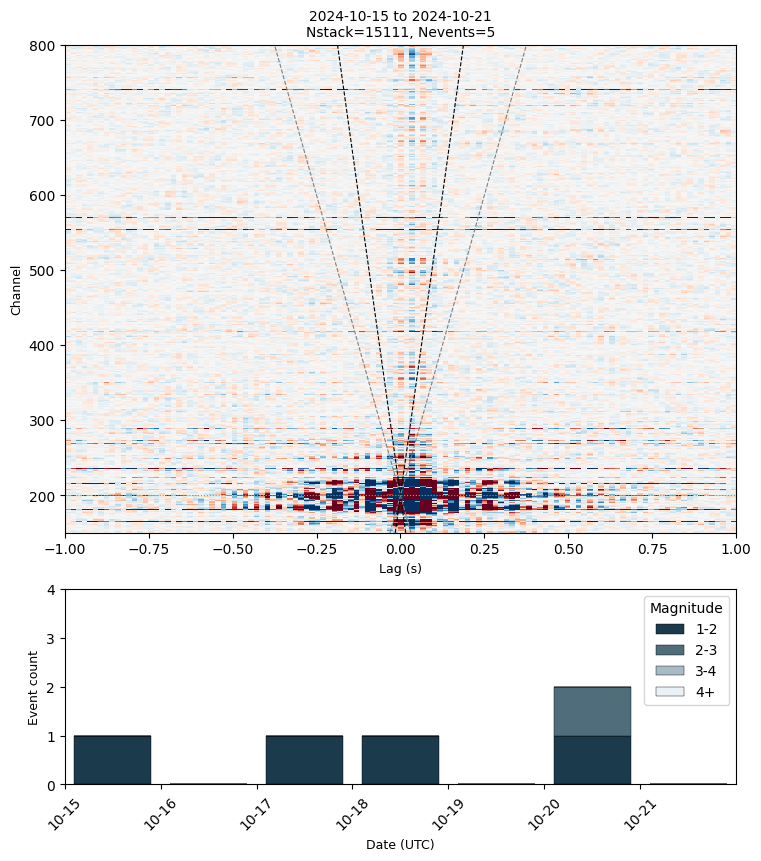

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-10-15_to_2024-10-21.png


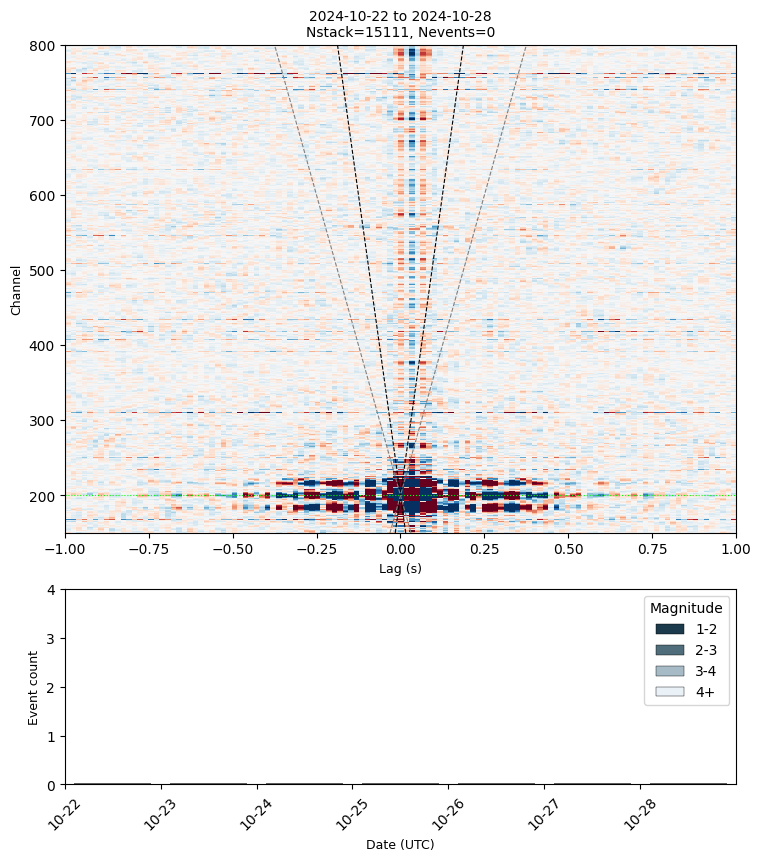

Saved /oak/stanford/groups/ettore88/nberrios/weekly_stacks_seismicity_day/weekly_stack_day_2024-10-22_to_2024-10-28.png


In [15]:
mask = np.abs(channels - src) > 10
out_dir = os.path.join(OUT_DIR, f'weekly_stacks_seismicity_{which}')
os.makedirs(out_dir, exist_ok=True)

for stack in stacks:
    fig, (ax_cc, ax_eq) = plt.subplots(
        2, 1,
        figsize=(7.5, 8.5),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [4, 1.6]},
    )

    cc = stack['cc']
    vlim = np.percentile(np.abs(cc[mask]), 99)
    ax_cc.imshow(
        cc,
        extent=[lags[0], lags[-1], ch_start, ch_end],
        origin='lower', aspect='auto',
        cmap='RdBu_r', vmin=-vlim, vmax=vlim,
        interpolation='nearest',
    )
    ax_cc.plot(+dist/vp, channels, '--', color='k',    lw=0.8, zorder=5)
    ax_cc.plot(-dist/vp, channels, '--', color='k',    lw=0.8, zorder=5)
    ax_cc.plot(+dist/vs, channels, '--', color='gray', lw=0.8, zorder=5)
    ax_cc.plot(-dist/vs, channels, '--', color='gray', lw=0.8, zorder=5)
    ax_cc.axhline(src, color='lime', lw=0.8, ls=':')
    ax_cc.set_xlim(-xlim_show, xlim_show)
    ax_cc.set_xlabel('Lag (s)')
    ax_cc.set_ylabel('Channel')
    ax_cc.set_title(
        f"{stack['date_start']} to {stack['date_end']}\n"
        f"Nstack={stack['nstack']}, Nevents={stack['nevents']}",
        fontsize=10,
    )

    events = stack['events'].copy()
    day_edges = pd.date_range(stack['start_utc'], stack['end_utc'], freq='1D')
    day_centers = day_edges[:-1] + pd.Timedelta(hours=12)
    counts = pd.DataFrame(0, index=day_centers, columns=MAG_LABELS, dtype=float)

    if len(events):
        events['mag_bin'] = pd.cut(
            events['magnitude'],
            bins=MAG_BINS,
            labels=MAG_LABELS,
            right=False,
            include_lowest=True,
        )
        events['day'] = events['time_utc'].dt.floor('D') + pd.Timedelta(hours=12)
        grouped = events.groupby(['day', 'mag_bin'], observed=False).size().unstack(fill_value=0)
        grouped = grouped.reindex(index=day_centers, columns=MAG_LABELS, fill_value=0)
        counts.loc[:, :] = grouped.to_numpy()

    x = mdates.date2num(counts.index.tz_localize(None).to_pydatetime())
    bottom = np.zeros(len(counts))
    for label, color in zip(MAG_LABELS, MAG_COLORS):
        ax_eq.bar(
            x,
            counts[label].to_numpy(),
            bottom=bottom,
            width=0.8,
            color=color,
            edgecolor='black',
            linewidth=0.3,
            align='center',
            label=label,
        )
        bottom += counts[label].to_numpy()

    ax_eq.set_xlim(
        mdates.date2num(stack['start_utc'].tz_localize(None).to_pydatetime()),
        mdates.date2num((stack['end_utc'] - pd.Timedelta(seconds=1)).tz_localize(None).to_pydatetime()),
    )
    ax_eq.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax_eq.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_eq.tick_params(axis='x', rotation=45)
    ax_eq.set_ylabel('Event count')
    ax_eq.set_xlabel('Date (UTC)')
    # ax_eq.set_ylim(0, max(1, counts.sum(axis=1).max()) + 0.5)
    ymax = int(counts.sum(axis=1).max())
    ax_eq.set_ylim(0, max(4, ymax))
    ax_eq.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax_eq.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

    ax_eq.legend(title='Magnitude', loc='upper right', frameon=True)

    out_png = os.path.join(
        out_dir,
        f"weekly_stack_{which}_{stack['date_start']}_to_{stack['date_end']}.png",
    )
    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_png}')

